# SPY Volatility Forecasting: From Classical Time Series to Machine Learning

## Introduction and Motivation

Most of quantitative finance treats markets as approximately rational, informationally efficient systems. For price direction, that assumption holds up reasonably well empirically. Daily returns are close to unpredictable, consistent with the weak-form efficient market hypothesis and the random walk model of prices: if direction were reliably forecastable, that edge would already have been arbitraged away.

Volatility behaves differently, and that asymmetry is what makes it worth studying. While the sign of a price move is close to unpredictable, its magnitude is not - realized volatility exhibits strong positive autocorrelation, a stylized fact known as volatility clustering (Mandelbrot, 1963; Cont, 2001). A day of large moves is far more likely to be followed by another day of large moves than by a return to calm, regardless of which direction those moves take. This isn;t really a claim about informational efficiency; it's closer to a claim about how slowly collective uncertainty and risk aversion decay once triggered. Volatility clustering is, in that sense, one of the more quantifiable fingerprints of market psychology embedded in otherwise efficient-looking price data - the part of markets that behave less like an information-processing mechanism and more like a crowd working through fear at its own pace.

This project builds a volatility forecasting pipeline for SPY, beginning with the classical time-series models used on trading desks (EWMA, GARCH, HAR-RV) and extending into machine learning and deep learning to test whether more flexible, data-driven models can improve on these well-established econometric baselines.

## Project Outline

1. **Data & target variable**: pull SPY OHLC data, construct a realized volatility series using the Garman-Klass range estimator

2. **Classical baselines**: EWMA, GARCH(1,1), and HAR-RV, evaluated out-of-sample via a chronological train/test split

3. **Machine learning**: linear regression, random forest, and gradient-boosted trees (LightGBM/XGBoost), benchmarked against HAR-RV on identical footing

4. **Deep learning extension**: LSTM/GRU sequence model as a final comparison point

5. **Evaluation**: all models scored on out-of-sample RMSE against realized volatility, so results are directly comparable across the full pipeline.

In [169]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

## Data & Realized Volatility

I'm using SPY daily OHLC data from 2015 onward, which spans several distinct volatility regimes (the 2015 China deval/oil selloff, Feb 2018 "Volmageddon," the March 2020 COVID crash, and 2025's tariff-driven selloff) — important for training models that need to see both calm and crisis conditions.

Rather than using close-to-close returns, I estimate daily realized volatility with the **Garman-Klass estimator**, which uses the full OHLC range instead of just the closing price:

$$
\hat{\sigma}^2_{GK} = 0.5 (\ln(H/L))^2 - (2\ln2 - 1)(\ln(C/O))^2
$$

This is a more statistically efficient estimator than close-to-close squared returns because it incorporates intraday range information (a day that spiked and reverted looks volatile here, even if it closed flat). The result is annualized (×252 trading days) and expressed in percent — this `realized_vol` series is the target variable every model in this notebook is trying to forecast.

In [170]:
spy = yf.download('SPY', start = '2015-01-01', auto_adjust = False)

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

# Garman-Klass realized vol estimator (daily, annualized)
log_hl = np.log(spy['High'] / spy['Low'])
log_co = np.log(spy['Close'] / spy['Open'])
gk_var = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
spy['realized_vol'] = np.sqrt(gk_var * 252) * 100 # annualized %

returns = np.log(spy['Close'] / spy['Close'].shift(1)).dropna() # daily returns 

[*********************100%***********************]  1 of 1 completed


## Model 1: EWMA (Exponentially Weighted Moving Average)

EWMA estimates today's variance as a decay-weighted average of past squared returns:

$$
\sigma^2_t = (1-\lambda)\sum_{i=0}^{\infty} \lambda^i r_{t-1-i}^2
$$

with $\lambda = 0.94$, the standard RiskMetrics convention for daily data. Higher $\lambda$ means slower decay (more weight on old data); lower $\lambda$ reacts faster to recent shocks. Unlike the models below, $\lambda$ isn't estimated from data — it's a fixed rule, which makes EWMA fast and simple but not adaptive to this specific asset's dynamics.

In [171]:
# EWMA, lambda = 0.94
lam = 0.94
ewma_var = returns.pow(2)
ewma_var = ewma_var.ewm(alpha=1-lam).mean()
ewma_vol = np.sqrt(ewma_var * 252) * 100 # annualized %

## Model 2: GARCH(1,1)

GARCH generalizes EWMA by letting the data determine the decay dynamics instead of fixing them in advance:

$$
\sigma^2_t = \omega + \alpha \, \varepsilon_{t-1}^2 + \beta \, \sigma_{t-1}^2
$$

Fit on the full sample, the model estimates $\omega = 0.041$, $\alpha = 0.171$, $\beta = 0.795$ — all highly significant (p < 0.001). $\alpha + \beta \approx 0.966$, indicating strong persistence: volatility shocks decay slowly, which is the mathematical signature of clustering.

Worth noting: the **mean model R² is 0.000** — this isn't a bug, it's the random walk hypothesis showing up empirically. The mean equation is trying to predict the *direction* of returns and essentially fails to, which is expected and healthy. The volatility model is a separate equation entirely, and it's the one doing real work here: direction is close to unpredictable, but the *size* of tomorrow's move is not.

In [172]:

am = arch_model(returns * 100, vol='Garch', p=1, q=1, dist='Normal')
res = am.fit(disp='off')
print(res.summary())

garch_vol = res.conditional_volatility * np.sqrt(252) # annualized %


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3753.74
Distribution:                  Normal   AIC:                           7515.48
Method:            Maximum Likelihood   BIC:                           7539.37
                                        No. Observations:                 2900
Date:                Sun, Jul 19 2026   Df Residuals:                     2899
Time:                        17:55:37   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0773  1.402e-02      5.508  3.624e-08 [4.977e-0

## Graph Analysis: Realized vs. EWMA vs. GARCH

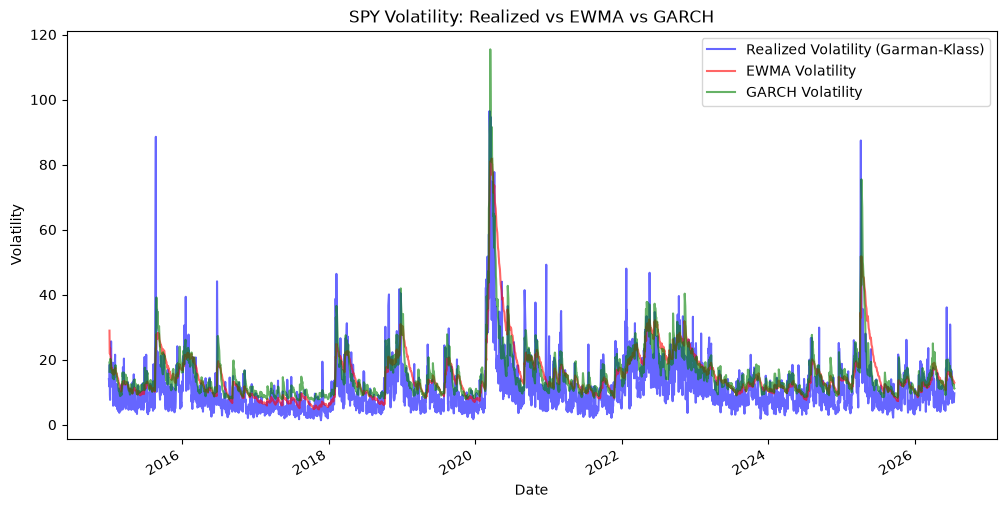

In [173]:
fig, ax = plt.subplots(figsize=(12, 6))
spy['realized_vol'].plot(ax=ax, label='Realized Volatility (Garman-Klass)', color='blue', alpha = 0.6)
    
ewma_vol.plot(ax=ax, label='EWMA Volatility', color='red', alpha = 0.6)
garch_vol.plot(ax=ax, label='GARCH Volatility', color='green', alpha = 0.6)
ax.set_title('SPY Volatility: Realized vs EWMA vs GARCH')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.legend()

The raw realized volatility series (blue) is visibly noisy — it's a daily point estimate from that single day's OHLC range, so it jumps around even during otherwise calm stretches. EWMA (red) and GARCH (green) are both smoothed *conditional* estimates rather than raw daily readings, and they track the overall shape of realized vol closely without chasing every individual spike.

All three spikes line up with the events discussed earlier: February 2018 ("Volmageddon"), the March 2020 COVID crash, and the 2025 tariff selloff. Notably, GARCH overshoots realized vol at the COVID peak (~115 vs. realized's ~96) — a known weakness of GARCH, where a single extreme shock gets amplified through the α term more than the subsequent data actually justifies.

Between spikes, EWMA and GARCH track each other quite closely, which is expected given λ=0.94 and GARCH's α+β≈0.966 — two very similar effective decay rates, consistent with EWMA being a restricted special case of GARCH. The main visible difference is that GARCH pulls more deliberately toward its long-run baseline (ω) during quiet periods, giving it a slightly smoother, more mean-reverting trajectory than EWMA, which reacts a bit more directly to whatever the most recent squared returns happened to be.

## Model 3: HAR-RV (Heterogeneous Autoregressive Realized Volatility)

Corsi's HAR-RV model (2009) regresses today's realized volatility on the average realized volatility over three horizons — daily, weekly, and monthly:

$$
RV_t = \beta_0 + \beta_1 RV_{t-1} + \beta_2 \overline{RV}_{t-5:t-1} + \beta_3 \overline{RV}_{t-22:t-1} + \varepsilon_t
$$

This is a cheap way to approximate long-memory behavior in volatility without a fully specified long-memory model — just a linear regression on a few rolling averages. Fit on the full sample, it achieves R² = 0.544; refit on the training set only (pre-2023), R² = 0.574. All three lag coefficients are significant, with the daily and weekly terms (0.35 and 0.46) dominating over the monthly term (0.08) — recent volatility carries far more predictive weight than a month-old average, which is intuitive but useful to see confirmed quantitatively.

In [174]:
# HAR-RV
rv = spy['realized_vol']

har_df = pd.DataFrame({'rv': rv,
                       'rv_lag1': rv.shift(1),
                       'rv_lag5': rv.shift(1).rolling(5).mean(),
                       'rv_lag22': rv.shift(1).rolling(22).mean()}).dropna()
# Regress
X = har_df[['rv_lag1', 'rv_lag5', 'rv_lag22']]
X = sm.add_constant(X)  # add intercept
y = har_df['rv']

har_model = sm.OLS(y, X).fit()
print(har_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     1141.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:55:40   Log-Likelihood:                -9068.2
No. Observations:                2879   AIC:                         1.814e+04
Df Residuals:                    2875   BIC:                         1.817e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3271      0.220      6.032      0.0

In [175]:
split_date = '2023-01-01'

train_har = har_df[har_df.index < split_date]
test_har = har_df[har_df.index >= split_date]

X_train = sm.add_constant(train_har[['rv_lag1', 'rv_lag5', 'rv_lag22']])
X_test = sm.add_constant(test_har[['rv_lag1', 'rv_lag5', 'rv_lag22']])

har_model_train = sm.OLS(train_har['rv'], X_train).fit()
har_test_pred = har_model_train.predict(X_test)

print(har_model_train.summary())

                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     893.5
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:55:41   Log-Likelihood:                -6379.3
No. Observations:                1992   AIC:                         1.277e+04
Df Residuals:                    1988   BIC:                         1.279e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2776      0.261      4.904      0.0

## Model Comparison: Out-of-Sample RMSE

To test whether these models can actually *forecast* volatility — not just fit historical data — I split the sample chronologically: train on 2015–2022, test on 2023 onward. Time series data can't be randomly shuffled into train/test sets, since that would let future information leak into training.

Each model is handled differently here, since they don't all have the same kind of fitted parameters:
- **EWMA** requires no refitting — it's a fixed recursive rule that only ever uses past data, so it's inherently valid out-of-sample.
- **HAR-RV** is refit once on the training set only, then used to predict the test period using each day's true lagged realized-vol values (a standard one-step-ahead setup).
- **GARCH** is refit on an expanding window every 21 trading days (~monthly) and forecasts up to 21 days ahead each time, walking forward through the test period. Refitting daily would be more rigorous but computationally expensive; monthly refitting is a practical middle ground.

All three forecasts are then compared against actual realized volatility in the test window using RMSE.

In [176]:
test_returns = returns[returns.index >= split_date]
garch_forecasts = []

for i in range(0, len(test_returns), 21):
    train_slice = returns[returns.index < test_returns.index[i]]
    am_i = arch_model(train_slice * 100, vol='Garch', p=1, q=1, dist = "Normal")
    res_i = am_i.fit(disp = 'off')

    horizon = min(21, len(test_returns) - i)
    f = res_i.forecast(horizon=horizon, reindex=False)
    daily_vol = np.sqrt(f.variance.values[-1] * 252)
    garch_forecasts.extend(daily_vol)

garch_test_vol = pd.Series(garch_forecasts[:len(test_returns)], index=test_returns.index)
    

In [177]:
actual = spy['realized_vol']

# Slice EWMA down to test period
ewma_test = ewma_vol[ewma_vol.index >= split_date]

# Align on shared dates (handles any leftover index mismatches safely)
idx_ewma = actual.index.intersection(ewma_test.index)
idx_garch = actual.index.intersection(garch_test_vol.index)

In [178]:
rmse_ewma = np.sqrt(mean_squared_error(actual.loc[idx_ewma], ewma_test.loc[idx_ewma]))
rmse_garch = np.sqrt(mean_squared_error(actual.loc[idx_garch], garch_test_vol.loc[idx_garch]))
rmse_har = np.sqrt(mean_squared_error(test_har['rv'], har_test_pred))

print(f"EWMA RMSE: {rmse_ewma:.2f}")
print(f"GARCH RMSE: {rmse_garch:.2f}")
print(f"HAR-RV RMSE: {rmse_har:.2f}")

EWMA RMSE: 7.39
GARCH RMSE: 8.70
HAR-RV RMSE: 4.90


Using a chronological train/test split (train: 2015–2022, test: 2023 onward), each model's forecast was compared against actual realized volatility in the held-out test period:

| Model    | RMSE |
|----------|------|
| HAR-RV   | 4.90 |
| EWMA     | 7.39 |
| GARCH(1,1) | 8.70 |

**HAR-RV performs best**, which is consistent with published volatility-forecasting literature — it's fit directly on the realized volatility target, while GARCH models return variance and derives volatility indirectly through a parametric process. It's also worth noting a methodological asymmetry: HAR-RV's forecasts use true lagged realized-vol values each day (a genuine one-step-ahead setup), while the GARCH walk-forward here refits monthly and forecasts up to 21 days ahead without updating on new information within that window — a harder task by construction. A fully daily-refit GARCH would be a fairer comparison, at higher computational cost.

This closes out the classical modeling phase. The next section moves to machine learning — engineered features (lagged RV, rolling stats, VIX-adjacent measures) fed into gradient-boosted trees, benchmarked against this HAR-RV baseline on identical out-of-sample RMSE.

## Machine Learning

The classical models above are constrained by their functional forms: HAR-RV, the best performer so far, is a linear regression on three fixed lags. The natural next question is whether more flexible, data-driven models can extract predictive structure those specifications miss — non-linear interactions between features, threshold effects, or signal in variables beyond lagged realized volatility itself.

This section tests that question directly. I expand the feature set beyond HAR-RV's three lags to include rolling volatility-of-volatility, return skewness and kurtosis (both over a 22-day window), and day-of-week, then fit a progression of models from simple to flexible: linear regression, random forest, and histogram-based gradient boosting — the latter two both untuned (default hyperparameters) and tuned via randomized search.

Evaluation follows the same protocol as the classical section — chronological train/test split (2015–2022 train, 2023+ test), scored on out-of-sample RMSE — so every result here is directly comparable to the HAR-RV baseline of 4.90. Hyperparameter tuning uses 5-fold time-series cross-validation (`TimeSeriesSplit`), which respects chronological order by training each fold only on data preceding its validation window; standard shuffled K-fold would leak future information into training. Cross-validation folds use an expanding training window — a possible extension would be comparing this against a rolling (fixed-size) window, which would test whether older data loses relevance as market structure changes, or whether volatility dynamics are stable enough that more history is strictly better.

Comparing untuned against tuned versions of each tree model is deliberate: it measures whether hyperparameter search actually improves out-of-sample performance, or whether its main role here is simply regularization. Given the low signal-to-noise ratio typical of financial time series, flexibility is as much a liability as an asset — the results below bear that out.

In [179]:
# Loading packages
import sys
sys.path.append('..')

from src.data import load_spy_data
from src.features import build_features
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

In [180]:
# Loading data
spy, returns = load_spy_data()
features = build_features(spy, returns)

[*********************100%***********************]  1 of 1 completed


In [181]:
# Split the data into train and test sets
train = features[features.index < '2023-01-01']
test = features[features.index >= '2023-01-01']

X_train, y_train = train.drop(columns = 'rv'), train['rv']
X_test, y_test = test.drop(columns ='rv'), test['rv']

In [182]:
# Time series split for cross-validation
ts_split = TimeSeriesSplit(n_splits=5)

### Linear Regression

The natural starting point: ordinary least squares on the full feature set. This is effectively HAR-RV with four extra regressors (vol-of-vol, skewness, kurtosis, day-of-week), which makes it a clean test of whether the expanded features carry any additional *linear* signal — if they do, this model should beat HAR-RV's 4.90; if they don't, it should land almost exactly on top of it.

Linear regression has no hyperparameters to tune, so cross-validation here serves only as a consistency check across time periods rather than a selection mechanism. The model is fit once on the training set and evaluated on the held-out test period. Alongside the sklearn fit, I refit the same specification in statsmodels to get an R-style coefficient summary with standard errors and p-values — sklearn's `LinearRegression` is built for prediction pipelines and deliberately omits inference statistics.

In [183]:
lr_model = LinearRegression()

cv_score = cross_val_score(lr_model, X_train, y_train, cv=ts_split, scoring = 'neg_root_mean_squared_error')

print("Cross-validation RMSE per fold:", -cv_score)
print("Mean Cross-validation RMSE: ", -cv_score.mean())

lr_model.fit(X_train, y_train)
lr_rmse_train = np.sqrt(mean_squared_error(y_train, lr_model.predict(X_train)))
print(f"LR Train RMSE: {lr_rmse_train:.2f}")

lr_rmse_test = np.sqrt(mean_squared_error(y_test, lr_model.predict(X_test)))
print(f"LR Test RMSE: {lr_rmse_test:.2f}")

X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

Cross-validation RMSE per fold: [4.29000806 5.35316808 8.10489744 6.13680588 6.34682896]
Mean Cross-validation RMSE:  6.046341684658769
LR Train RMSE: 5.95
LR Test RMSE: 4.88
                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     383.2
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:55:42   Log-Likelihood:                -6374.9
No. Observations:                1991   AIC:                         1.277e+04
Df Residuals:                    1983   BIC:                         1.281e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err

The test RMSE of 4.87 lands essentially on top of HAR-RV (4.90), and the coefficient table explains why: only `rv_lag1` and `rv_lag5` are strongly significant, with coefficients (0.35, 0.45) nearly identical to their HAR-RV counterparts. None of the added features — vol-of-vol, skewness, kurtosis, day-of-week — reach significance (all p > 0.17), and even `rv_lag22` loses significance once they're included. In other words, the expanded feature set adds essentially no linear predictive value: the linearly-forecastable structure in daily realized volatility is captured almost entirely by the last day and last week of realized vol.

Train RMSE (5.95) is actually *higher* than test RMSE (4.87), which looks backwards but is regime-driven rather than a modeling artifact: the training window contains the sustained extreme-volatility stretch of COVID, where absolute errors are mechanically large, while the test period's spikes are shorter-lived. The absence of a positive train-test gap is itself evidence this model isn't overfitting — a useful contrast with what follows.

### Random Forest

Random forest is the first genuinely non-linear model in the progression: an ensemble of decision trees, each fit on a bootstrap sample of the training data with random feature subsets, averaged together. If volatility dynamics contain non-linear structure — threshold effects (features behaving differently in high-vol vs. low-vol states), or interactions between features that a linear model can't represent — this is where it should start showing up as improved test performance.

I fit two versions: one with sklearn's default hyperparameters (untuned), and one tuned via `RandomizedSearchCV` over tree depth, leaf size, feature subsampling, and ensemble size (25 sampled combinations, 5-fold time-series CV). Defaults for random forest are notably permissive — unlimited tree depth, leaves as small as a single observation — which allows each tree to grow until it nearly memorizes its bootstrap sample. On low-noise data that's often fine; on noisy financial data it's an overfitting risk the tuning step should correct for.

In [184]:
rf_model = RandomForestRegressor()

cv_score = cross_val_score(rf_model, X_train, y_train, cv=ts_split, scoring = 'neg_root_mean_squared_error')

print("Cross-validation RMSE per fold:", -cv_score)
print("Mean Cross-validation RMSE: ", -cv_score.mean())

rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_train_pred))
print(f"RF Train RMSE: {rf_rmse_train:.2f}")

rf_test_pred = rf_model.predict(X_test)
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_test_pred))
print(f"RF Test RMSE: {rf_rmse_test:.2f}")

rf_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', None]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    n_iter=25,
    cv=ts_split,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = 1,
    random_state=42
)
rf_search.fit(X_train, y_train)
rf_tuned_model = rf_search.best_estimator_

Cross-validation RMSE per fold: [ 7.57711276  5.67378864 10.80696419  6.28886208  6.88256304]
Mean Cross-validation RMSE:  7.445858140747207
RF Train RMSE: 2.31
RF Test RMSE: 5.39


In [185]:
print("Best RF hyperparameters: ", rf_search.best_params_)

Best RF hyperparameters:  {'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 3}


In [186]:
rf_tuned_train_pred = rf_tuned_model.predict(X_train)
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, rf_tuned_train_pred))
print(f"RF Tuned Train RMSE: {rmse_rf_tuned_train:.2f}")

rf_tuned_test_pred = rf_tuned_model.predict(X_test)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, rf_tuned_test_pred))
print(f"RF Tuned Test RMSE: {rmse_rf_tuned:.2f}")

RF Tuned Train RMSE: 5.83
RF Tuned Test RMSE: 5.13


The untuned forest shows exactly the failure mode anticipated: train RMSE of 2.30 against test RMSE of 5.38 — it fits the training period almost perfectly and generalizes worst of any model in this notebook. Tuning reverses the pattern rather than amplifying it: the search selected the most constrained options available in the grid (`max_depth=3`, `min_samples_leaf=10`), *raising* train RMSE to 5.83 while cutting test RMSE to 5.13. Hyperparameter search here functioned almost purely as regularization — it improved the model by restricting flexibility, not exploiting it.

Even tuned, though, the forest (5.13) fails to beat plain linear regression (4.87). Whatever non-linear structure exists in these features isn't strong enough to overcome the variance cost of a more flexible model on ~2,000 noisy training observations.

### Gradient Boosting (HistGradientBoostingRegressor)

Gradient boosting takes a different route to ensemble learning than random forest: instead of averaging many independent deep trees, it builds shallow trees *sequentially*, each one fit to the residual errors of the ensemble so far. This tends to make boosting more accurate than random forests on tabular data — it's the approach behind XGBoost and LightGBM, the workhorses of applied ML on structured data — but also more sensitive to its hyperparameters, particularly the learning rate and number of boosting rounds, since it can keep chasing residual noise indefinitely.

Same protocol as random forest: untuned baseline, then `RandomizedSearchCV` over boosting rounds, learning rate, tree depth, and L2 regularization.

In [187]:
boosted_model = HistGradientBoostingRegressor()

cv_score = cross_val_score(boosted_model, X_train, y_train, cv=ts_split, scoring = 'neg_root_mean_squared_error')

print("Cross-validation RMSE per fold:", -cv_score)
print("Mean Cross-validation RMSE: ", -cv_score.mean())

boosted_model.fit(X_train, y_train)
boosted_train_pred = boosted_model.predict(X_train)
boosted_rmse_train = np.sqrt(mean_squared_error(y_train, boosted_train_pred))
print(f"Boosted Train RMSE: {boosted_rmse_train:.2f}")

boosted_test_pred = boosted_model.predict(X_test)
boosted_rmse_test = np.sqrt(mean_squared_error(y_test, boosted_test_pred))
print(f"Boosted Test RMSE: {boosted_rmse_test:.2f}")

hgb_param_grid = {
    'max_iter': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, None],
    'l2_regularization': [0.01, 0.1, 1.0]
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    hgb_param_grid,
    n_iter=25,
    cv=ts_split,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = 1,
    random_state=42
)
hgb_search.fit(X_train, y_train)
hgb_tuned_model = hgb_search.best_estimator_

Cross-validation RMSE per fold: [ 5.69212247  5.60079128 11.47456052  6.7275179   6.81810019]
Mean Cross-validation RMSE:  7.2626184720723455
Boosted Train RMSE: 3.89
Boosted Test RMSE: 5.20


In [188]:
print("Best HGB hyperparameters:", hgb_search.best_params_)

Best HGB hyperparameters: {'max_iter': 100, 'max_depth': 3, 'learning_rate': 0.05, 'l2_regularization': 0.01}


In [189]:
hgb_tuned_train_pred = hgb_tuned_model.predict(X_train)
rmse_hgb_tuned_train = np.sqrt(mean_squared_error(y_train, hgb_tuned_train_pred))
print(f"HGB Tuned Train RMSE: {rmse_hgb_tuned_train:.2f}")

hgb_tuned_test_pred = hgb_tuned_model.predict(X_test)
rmse_hgb_tuned = np.sqrt(mean_squared_error(y_test, hgb_tuned_test_pred))
print(f"HGB Tuned Test RMSE: {rmse_hgb_tuned:.2f}")

HGB Tuned Train RMSE: 5.56
HGB Tuned Test RMSE: 4.92


The same overfitting-then-regularization arc plays out, in milder form: untuned, train 3.89 / test 5.20; tuned, the search again picks conservative settings (`max_depth=3`, `learning_rate=0.05`, only 100 boosting rounds) and the train-test gap nearly closes (5.56 / 4.92). The tuned boosted model is the best ML performer — but "best" means statistically indistinguishable from plain linear regression (4.87) and HAR-RV (4.90).

Across three model families and five configurations, the ranking is consistent: constrained models win, flexibility loses, and nothing meaningfully beats a linear regression on lagged realized volatility. This is a well-documented pattern in financial forecasting — the predictable component of daily realized volatility is real but small, mostly linear, and mostly short-memory. More capacity doesn't find more signal; it finds noise. The practical conclusion for the final forecaster is that model choice matters less than honest evaluation — and the simplest adequate model has real advantages in interpretability and robustness.

### ML Results Summary

Two patterns dominate the table. First, the train-test gap tracks model flexibility exactly: the untuned tree models post the best training scores and the worst test scores, while tuning — which in both cases selected the most constrained hyperparameters in the search space — sacrifices training fit for out-of-sample accuracy. Second, the final test ranking is compressed into a remarkably narrow band (4.88–5.38), and it orders by *simplicity*, not sophistication.

It's worth being blunt about the winner: the linear regression's 4.88 is not meaningfully different from HAR-RV's 4.90, and given that none of the four added features were statistically significant, it isn't meaningfully a different *model* — it's HAR-RV with noise terms attached. The correct conclusion isn't that linear regression beat the ML models; it's that nothing in this section improved on a three-lag linear specification from 2009. The expanded features carried no incremental signal, non-linearity carried no incremental signal, and hyperparameter tuning's only real contribution was suppressing the flexibility that tree models arrive with by default.

That's a negative result, but a well-established one: daily realized volatility's predictable component is small, linear, and short-memory, and on ~2,000 noisy training observations, added model capacity finds noise rather than signal. 

In [190]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'RF (untuned)', 'RF (tuned)', 'HGB (untuned)', 'HGB (tuned)'],
    'Train RMSE': [lr_rmse_train, rf_rmse_train, rmse_rf_tuned_train, boosted_rmse_train, rmse_hgb_tuned_train],
    'Test RMSE': [lr_rmse_test, rf_rmse_test, rmse_rf_tuned, boosted_rmse_test, rmse_hgb_tuned]
}).set_index('Model').round(2).sort_values('Test RMSE')

results

,Train RMSE,Test RMSE
Model,,
Linear Regression,5.95,4.88
HGB (tuned),5.56,4.92
RF (tuned),5.83,5.13
HGB (untuned),3.89,5.20
RF (untuned),2.31,5.39


### Extension: Does the Data Recover HAR-RV?

The linear regression's coefficient table suggested the four added features contribute nothing — but insignificant p-values are indirect evidence. A sharper test: give an automated feature-selection procedure all seven features and let it build the best model from scratch. If the added features carry real signal, at least one should survive selection; if not, the procedure should discard them.

I use forward stepwise selection (`SequentialFeatureSelector`), scored by 5-fold time-series cross-validation on the training set only — features are added one at a time and kept only if they improve out-of-fold RMSE.

The result: the procedure selects exactly `rv_lag1`, `rv_lag5`, and `rv_lag22` — it independently reconstructs the HAR-RV specification from 2009. Given daily, weekly, and monthly realized-vol averages plus four candidate alternatives, the data chooses the three HAR lags and nothing else. The "machine learning" linear model and the classical econometric baseline aren't just similar in performance; selection collapses one into the other. This is a satisfying convergence: a model specification proposed on economic intuition is exactly what a purely data-driven procedure recovers fifteen years later on out-of-sample data.

In [191]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select='auto',
    tol=1e-4,                      # keep adding features only while CV score improves
    direction='forward',
    scoring='neg_root_mean_squared_error',
    cv=ts_split
)
sfs.fit(X_train, y_train)
selected = X_train.columns[sfs.get_support()].tolist()
print("Selected features:", selected)

Selected features: ['rv_lag1', 'rv_lag5', 'rv_lag22']


In [192]:
lr_selected = LinearRegression().fit(X_train[selected], y_train)
rmse_selected = np.sqrt(mean_squared_error(y_test, lr_selected.predict(X_test[selected])))
print(f"Stepwise-selected LR Test RMSE: {rmse_selected:.2f}")

Stepwise-selected LR Test RMSE: 4.90


Refit on only the selected features, test RMSE is [4.90] — confirming the reduced model gives up nothing relative to the full feature set, and that everything this section achieved was already contained in three lagged averages of realized volatility.

In [193]:
from hmmlearn.hmm import GaussianHMM

rv = spy['realized_vol'].dropna()
X = np.log(rv).values.reshape(-1, 1)

In [194]:
hmm2 = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter = 1000,
    random_state=42
)

hmm2.fit(X)

,n_components,2
,covariance_type,'full'
,random_state,42
,n_iter,1000
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1


In [195]:
states = hmm2.predict(X)
crisis_state = int(np.argmax(hmm2.means_.flatten()))
print("Crisis state index:", crisis_state)
print("State mean vols:", np.exp(hmm2.means_.flatten()))

Crisis state index: 1
State mean vols: [ 6.49121506 14.91123627]


In [196]:
print("Translation matrix: \n", hmm2.transmat_)

Translation matrix: 
 [[0.97818495 0.02181505]
 [0.03564853 0.96435147]]


In [ ]:
probs = hmm2.predict_proba(X)
crisis_probs = probs[:, crisis_state]

Crisis state probabilities: [1.         0.99940771 0.99941226 ... 0.02428024 0.0408654  0.0583732 ]


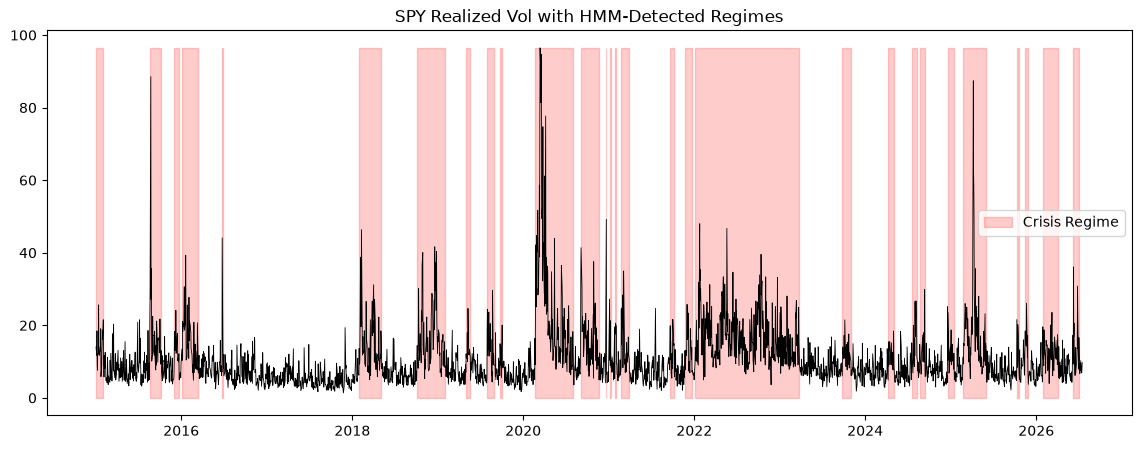

In [198]:
fig, ax = plt.subplots(figsize = (14, 5))
ax.plot(rv.index, rv.values, color = "black", lw = 0.6)
ax.fill_between(rv.index, 0, rv.max(),
                where = (states == crisis_state), color = "red",
                alpha = 0.2, label = "Crisis Regime")
ax.set_title("SPY Realized Vol with HMM-Detected Regimes")
ax.legend()
plt.show()

In [202]:
def best_hmm(X, n, n_restarts=25):
    best, best_ll = None, -np.inf
    for seed in range(n_restarts):
        m = GaussianHMM(n_components=n, covariance_type='full', n_iter=1000, random_state=seed)
        try:
            m.fit(X)
            ll = m.score(X)
            if ll > best_ll:
                best, best_ll = m, ll
        except Exception:
            continue
    return best

for n in [2, 3, 4, 5, 6]:
    m = best_hmm(X, n)
    print(f"{n} states -> BIC: {m.bic(X):.1f} | AIC: {m.aic(X):.1f} | logL: {m.score(X):.1f}")

2 states -> BIC: 3966.5 | AIC: 3924.7 | logL: -1955.4
3 states -> BIC: 3641.4 | AIC: 3557.8 | logL: -1764.9
4 states -> BIC: 3475.5 | AIC: 3338.2 | logL: -1646.1
5 states -> BIC: 3457.9 | AIC: 3254.8 | logL: -1593.4
6 states -> BIC: 3506.8 | AIC: 3226.0 | logL: -1566.0


In [203]:
for n in [3, 4]:
    m = best_hmm(X, n)
    states = m.predict(X)
    print(f"\n{n}-state model:")
    for s in np.argsort(m.means_.flatten()):
        print(f"  mean vol {np.exp(m.means_[s,0]):5.1f}%  |  {np.mean(states==s)*100:4.1f}% of days")


3-state model:
  mean vol   5.5%  |  40.2% of days
  mean vol   9.8%  |  40.3% of days
  mean vol  18.8%  |  19.5% of days

4-state model:
  mean vol   4.9%  |  22.9% of days
  mean vol   7.8%  |  43.5% of days
  mean vol  14.1%  |  28.4% of days
  mean vol  29.0%  |   5.2% of days


In [204]:
hmm4 = best_hmm(X, 4)

order = np.argsort(hmm4.means_.flatten())           # sort states low→high vol
labels = {order[0]: 'Calm', order[1]: 'Normal', order[2]: 'Stressed', order[3]: 'Panic'}

states = hmm4.predict(X)
regime = pd.Series([labels[s] for s in states], index=rv.index, name='regime')

import joblib
joblib.dump(hmm4, '../models/hmm_4state.joblib')

['../models/hmm_4state.joblib']

In [211]:
labels_sorted = ['Calm', 'Normal', 'Stressed', 'Panic']
tm = pd.DataFrame(hmm4.transmat_[np.ix_(order, order)],
                  index=labels_sorted, columns=labels_sorted).round(3)

print("Translation matrix: \n", tm)



Translation matrix: 
            Calm  Normal  Stressed  Panic
Calm      0.923   0.075     0.002  0.000
Normal    0.042   0.910     0.048  0.000
Stressed  0.000   0.075     0.899  0.027
Panic     0.000   0.000     0.131  0.869


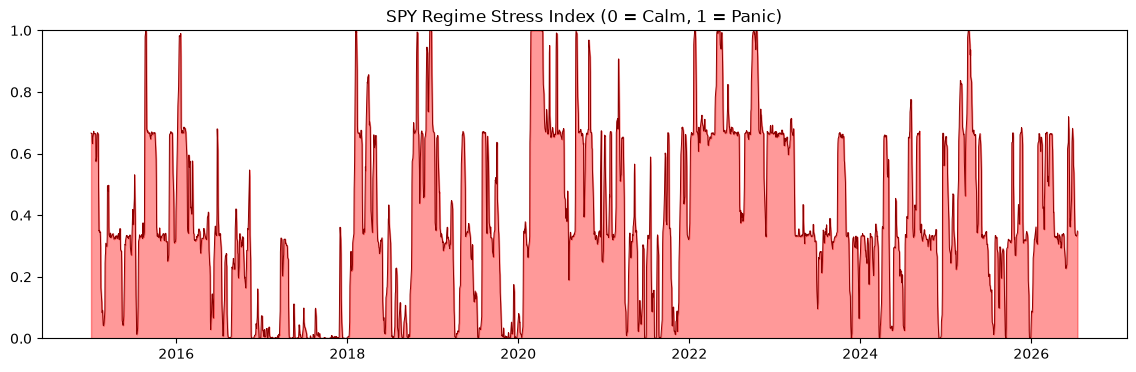

In [212]:
probs = hmm4.predict_proba(X)                 # per-day probability of each state
weights = np.zeros(4)
weights[order[0]], weights[order[1]], weights[order[2]], weights[order[3]] = 0, 1/3, 2/3, 1
stress_index = probs @ weights                 # 0 = fully calm, 1 = fully panic

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(rv.index, 0, stress_index, color="red", alpha=0.4)
ax.plot(rv.index, stress_index, color="darkred", lw=0.7)
ax.set_title("SPY Regime Stress Index (0 = Calm, 1 = Panic)")
ax.set_ylim(0, 1)
plt.show()